# FGSM / Edge-FGSM Dataset Generation

In [1]:
# 1. Setup
from google.colab import drive
import os, shutil, random, json, math, time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import save_image

import matplotlib.pyplot as plt

drive.mount('/content/drive')

DRIVE_BASE_DIR = '/content/drive/MyDrive/26sp_ML/ML_project'
GTSRB_ZIP_DRIVE = os.path.join(DRIVE_BASE_DIR, 'GTSRB.zip')
MODEL_PATH = os.path.join(DRIVE_BASE_DIR, 'resnet18_gtsrb_best_full_model.pth')

LOCAL_BASE_DIR = '/content'
LOCAL_ZIP_PATH = '/content/GTSRB.zip'
LOCAL_EXTRACT_DIR = '/content/gtsrb_data'

IMG_SIZE = 224
NUM_CLASSES = 43
BATCH_SIZE = 64
GENERATION_NUM_WORKERS = 2
EVALUATION_NUM_WORKERS = 0

FGSM_EPS_LIST = [2, 4, 8, 16]
EDGE_EPS_LIST = [5, 10, 15, 30]

EDGE_THRESHOLD = 0.25
DILATION_KERNEL = 15
EDGE_WEIGHT = 0.8
NON_EDGE_WEIGHT = 0.2

FORCE_REGENERATE = False
SAVE_ZIPS_TO_DRIVE = True

RANDOM_SEED = 42
N_PIXEL_SAMPLE = 500

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [2]:
# 2. Load GTSRB test data
if not os.path.exists(LOCAL_ZIP_PATH):
    shutil.copy2(GTSRB_ZIP_DRIVE, LOCAL_ZIP_PATH)

if not os.path.exists(LOCAL_EXTRACT_DIR):
    os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
    shutil.unpack_archive(LOCAL_ZIP_PATH, LOCAL_EXTRACT_DIR)

def find_gtsrb_root(search_root):
    for dirpath, _, filenames in os.walk(search_root):
        if 'Test.csv' in filenames:
            return dirpath

GTSRB_ROOT = find_gtsrb_root(LOCAL_EXTRACT_DIR)
TEST_CSV = os.path.join(GTSRB_ROOT, 'Test.csv')
test_df = pd.read_csv(TEST_CSV).reset_index(drop=True)

print('GTSRB root:', GTSRB_ROOT)
print('Test images:', len(test_df))
test_df.head()


GTSRB root: /content/gtsrb_data
Test images: 12630


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [3]:
# 3. Dataset and dataloader
plain_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class GTSRBImageDataset(Dataset):
    def __init__(self, df, root_dir, transform):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.root_dir, row['Path'])).convert('RGB')
        return self.transform(img), int(row['ClassId']), row['Path']

clean_dataset = GTSRBImageDataset(test_df, GTSRB_ROOT, plain_transform)
clean_loader = DataLoader(
    clean_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=GENERATION_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Dataset size:', len(clean_dataset))

Dataset size: 12630


In [4]:
# 4. Load fine-tuned ResNet-18
model = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model = model.to(DEVICE).eval()
criterion = nn.CrossEntropyLoss()

mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

def normalize_batch(x):
    return (x - mean) / std

print('Model loaded:', MODEL_PATH)

Model loaded: /content/drive/MyDrive/26sp_ML/ML_project/resnet18_gtsrb_best_full_model.pth


In [5]:
# 5. Edge mask for Edge-FGSM
def sobel_magnitude_batch(x):
    gray = 0.2989 * x[:, 0:1] + 0.5870 * x[:, 1:2] + 0.1140 * x[:, 2:3]

    sobel_x = torch.tensor(
        [[[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]]],
        dtype=x.dtype,
        device=x.device,
    )
    sobel_y = torch.tensor(
        [[[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]]],
        dtype=x.dtype,
        device=x.device,
    )

    gray = F.pad(gray, (1, 1, 1, 1), mode='replicate')
    mag = torch.sqrt(F.conv2d(gray, sobel_x) ** 2 + F.conv2d(gray, sobel_y) ** 2 + 1e-12)

    flat = mag.flatten(1)
    mag_min = flat.min(1)[0].view(-1, 1, 1, 1)
    mag_max = flat.max(1)[0].view(-1, 1, 1, 1)
    return (mag - mag_min) / (mag_max - mag_min + 1e-8)

def edge_mask_batch(x):
    edge = sobel_magnitude_batch(x)
    mask = (edge > EDGE_THRESHOLD).float()
    mask = F.max_pool2d(mask, kernel_size=DILATION_KERNEL, stride=1, padding=DILATION_KERNEL // 2)
    return edge, mask

In [6]:
# 6. Output folders
ATTACK_BASE_DIR = os.path.join(LOCAL_BASE_DIR, 'attack_FGSM')

def fgsm_root(eps_255):
    return os.path.join(ATTACK_BASE_DIR, f'FGSM_eps{eps_255}_255')

def edge_root(eps_255):
    return os.path.join(ATTACK_BASE_DIR, f'EdgeFGSM_eps{eps_255}_255')

attack_roots = {
    **{f'FGSM {e}/255': fgsm_root(e) for e in FGSM_EPS_LIST},
    **{f'Edge-FGSM {e}/255': edge_root(e) for e in EDGE_EPS_LIST},
}

for root in attack_roots.values():
    os.makedirs(root, exist_ok=True)

In [7]:
# 7. Generate FGSM and Edge-FGSM datasets
def attack_done(root):
    csv_path = os.path.join(root, 'Test.csv')
    return os.path.exists(csv_path) and len(pd.read_csv(csv_path)) == len(test_df)

need_generate = FORCE_REGENERATE or not all(attack_done(root) for root in attack_roots.values())

if not need_generate:
    print('Attacked datasets already exist')

if need_generate:
    start_time = time.time()
    model.eval()

    for images, labels, rel_paths in tqdm(clean_loader, desc='Generating attacks'):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        x = images.clone().detach().requires_grad_(True)
        model.zero_grad(set_to_none=True)
        loss = criterion(model(normalize_batch(x)), labels)
        loss.backward()

        grad_sign = x.grad.detach().sign()
        clean_images = x.detach()

        with torch.no_grad():
            _, mask = edge_mask_batch(clean_images)
            edge_weight = EDGE_WEIGHT * mask + NON_EDGE_WEIGHT * (1.0 - mask)
            edge_weight = edge_weight.repeat(1, 3, 1, 1)

            for eps_255 in FGSM_EPS_LIST:
                adv = torch.clamp(clean_images + (eps_255 / 255.0) * grad_sign, 0.0, 1.0)
                root = fgsm_root(eps_255)
                for i, rel_path in enumerate(rel_paths):
                    save_path = os.path.join(root, rel_path)
                    os.makedirs(os.path.dirname(save_path), exist_ok=True)
                    save_image(adv[i].cpu(), save_path)

            for eps_255 in EDGE_EPS_LIST:
                adv = torch.clamp(clean_images + (eps_255 / 255.0) * edge_weight * grad_sign, 0.0, 1.0)
                root = edge_root(eps_255)
                for i, rel_path in enumerate(rel_paths):
                    save_path = os.path.join(root, rel_path)
                    os.makedirs(os.path.dirname(save_path), exist_ok=True)
                    save_image(adv[i].cpu(), save_path)

    for name, root in attack_roots.items():
        test_df.to_csv(os.path.join(root, 'Test.csv'), index=False)
        with open(os.path.join(root, 'attack_config.json'), 'w') as f:
            json.dump({
                'attack': name,
                'img_size': IMG_SIZE,
                'edge_threshold': EDGE_THRESHOLD,
                'dilation_kernel': DILATION_KERNEL,
                'edge_weight': EDGE_WEIGHT,
                'non_edge_weight': NON_EDGE_WEIGHT,
            }, f, indent=2)

Generating attacks:   0%|          | 0/198 [00:00<?, ?it/s]

In [8]:
# 8. Zip generated datasets to Google Drive
if SAVE_ZIPS_TO_DRIVE:
    ZIP_SAVE_DIR = os.path.join(DRIVE_BASE_DIR, 'attack_FGSM')
    os.makedirs(ZIP_SAVE_DIR, exist_ok=True)

    for root in attack_roots.values():
        zip_path = shutil.make_archive(root, 'zip', root)
        shutil.copy2(zip_path, os.path.join(ZIP_SAVE_DIR, os.path.basename(zip_path)))

    print('Zip saved :', ZIP_SAVE_DIR)

Zip saved : /content/drive/MyDrive/26sp_ML/ML_project/attack_FGSM


In [9]:
# 9. Evaluate clean and attacked datasets
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class GTSRBEvalDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.df = pd.read_csv(os.path.join(root_dir, 'Test.csv')).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.root_dir, row['Path'])).convert('RGB')
        return eval_transform(img), int(row['ClassId'])

@torch.no_grad()
def evaluate_root(root_dir, name):
    loader = DataLoader(
        GTSRBEvalDataset(root_dir),
        batch_size=128,
        shuffle=False,
        num_workers=EVALUATION_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    correct = 0
    total = 0
    model.eval()

    for images, labels in tqdm(loader, desc=name):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return {'attack': name, 'accuracy': correct / total, 'correct': correct, 'total': total, 'root': root_dir}

eval_rows = [evaluate_root(GTSRB_ROOT, 'Clean')]
eval_rows += [evaluate_root(fgsm_root(e), f'FGSM {e}/255') for e in FGSM_EPS_LIST]
eval_rows += [evaluate_root(edge_root(e), f'Edge-FGSM {e}/255') for e in EDGE_EPS_LIST]

summary_dir = os.path.join(ATTACK_BASE_DIR, 'summary')
os.makedirs(summary_dir, exist_ok=True)

accuracy_df = pd.DataFrame(eval_rows)
accuracy_df.to_csv(os.path.join(summary_dir, 'accuracy_summary.csv'), index=False)
display(accuracy_df)

Clean:   0%|          | 0/99 [00:00<?, ?it/s]

FGSM 2/255:   0%|          | 0/99 [00:00<?, ?it/s]

FGSM 4/255:   0%|          | 0/99 [00:00<?, ?it/s]

FGSM 8/255:   0%|          | 0/99 [00:00<?, ?it/s]

FGSM 16/255:   0%|          | 0/99 [00:00<?, ?it/s]

Edge-FGSM 5/255:   0%|          | 0/99 [00:00<?, ?it/s]

Edge-FGSM 10/255:   0%|          | 0/99 [00:00<?, ?it/s]

Edge-FGSM 15/255:   0%|          | 0/99 [00:00<?, ?it/s]

Edge-FGSM 30/255:   0%|          | 0/99 [00:00<?, ?it/s]

,attack,accuracy,correct,total,root
0,Clean,0.994695,12563,12630,/content/gtsrb_data
1,FGSM 2/255,0.864766,10922,12630,/content/attack_FGSM/FGSM_eps2_255
2,FGSM 4/255,0.788757,9962,12630,/content/attack_FGSM/FGSM_eps4_255
3,FGSM 8/255,0.678147,8565,12630,/content/attack_FGSM/FGSM_eps8_255
4,FGSM 16/255,0.459382,5802,12630,/content/attack_FGSM/FGSM_eps16_255
5,Edge-FGSM 5/255,0.835709,10555,12630,/content/attack_FGSM/EdgeFGSM_eps5_255
6,Edge-FGSM 10/255,0.743389,9389,12630,/content/attack_FGSM/EdgeFGSM_eps10_255
7,Edge-FGSM 15/255,0.649327,8201,12630,/content/attack_FGSM/EdgeFGSM_eps15_255
8,Edge-FGSM 30/255,0.348535,4402,12630,/content/attack_FGSM/EdgeFGSM_eps30_255


In [10]:
# 10. Mean pixel change summary
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sample_indices = random.sample(range(len(test_df)), N_PIXEL_SAMPLE)
sample_df = test_df.iloc[sample_indices].reset_index(drop=True).copy()
sample_df['original_index'] = sample_indices

def load_rgb_tensor(root, rel_path):
    img = Image.open(os.path.join(root, rel_path)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1)

def pixel_change_root(root, name):
    rows = []
    for row in tqdm(sample_df.itertuples(index=False), total=len(sample_df), desc=name):
        clean = load_rgb_tensor(GTSRB_ROOT, row.Path)
        attacked = load_rgb_tensor(root, row.Path)
        diff = (attacked - clean).abs()
        rows.append({
            'attack': name,
            'original_index': int(row.original_index),
            'Path': row.Path,
            'ClassId': int(row.ClassId),
            'mean_abs_pixel_change_per_image': diff.mean().item(),
            'max_abs_pixel_change_per_image': diff.max().item(),
            'rmse_per_image': torch.sqrt((diff ** 2).mean()).item(),
        })
    return pd.DataFrame(rows)

pixel_detail_df = pd.concat(
    [pixel_change_root(fgsm_root(e), f'FGSM {e}/255') for e in FGSM_EPS_LIST] +
    [pixel_change_root(edge_root(e), f'Edge-FGSM {e}/255') for e in EDGE_EPS_LIST],
    ignore_index=True,
)

pixel_summary_df = pixel_detail_df.groupby('attack', as_index=False).agg(
    num_samples_used=('mean_abs_pixel_change_per_image', 'count'),
    mean_of_mean_abs_pixel_change=('mean_abs_pixel_change_per_image', 'mean'),
    std_of_mean_abs_pixel_change=('mean_abs_pixel_change_per_image', 'std'),
    mean_of_max_abs_pixel_change=('max_abs_pixel_change_per_image', 'mean'),
    mean_rmse=('rmse_per_image', 'mean'),
)

pixel_detail_df.to_csv(os.path.join(summary_dir, f'pixel_change_detail_{N_PIXEL_SAMPLE}_seed{RANDOM_SEED}.csv'), index=False)
pixel_summary_df.to_csv(os.path.join(summary_dir, f'pixel_change_summary_{N_PIXEL_SAMPLE}_seed{RANDOM_SEED}.csv'), index=False)
display(pixel_summary_df)

FGSM 2/255:   0%|          | 0/500 [00:00<?, ?it/s]

FGSM 4/255:   0%|          | 0/500 [00:00<?, ?it/s]

FGSM 8/255:   0%|          | 0/500 [00:00<?, ?it/s]

FGSM 16/255:   0%|          | 0/500 [00:00<?, ?it/s]

Edge-FGSM 5/255:   0%|          | 0/500 [00:00<?, ?it/s]

Edge-FGSM 10/255:   0%|          | 0/500 [00:00<?, ?it/s]

Edge-FGSM 15/255:   0%|          | 0/500 [00:00<?, ?it/s]

Edge-FGSM 30/255:   0%|          | 0/500 [00:00<?, ?it/s]

,attack,num_samples_used,mean_of_mean_abs_pixel_change,std_of_mean_abs_pixel_change,mean_of_max_abs_pixel_change,mean_rmse
0,Edge-FGSM 10/255,500,0.019615,0.004048,0.093663,0.024083
1,Edge-FGSM 15/255,500,0.029100,0.005975,0.109349,0.034801
2,Edge-FGSM 30/255,500,0.057302,0.011782,0.156408,0.067200
3,Edge-FGSM 5/255,500,0.010591,0.002439,0.077976,0.014014
4,FGSM 16/255,500,0.060601,0.003806,0.125043,0.062065
5,FGSM 2/255,500,0.009282,0.001657,0.070180,0.011306
6,FGSM 4/255,500,0.016043,0.001019,0.077984,0.017694
7,FGSM 8/255,500,0.030757,0.001648,0.093671,0.032167


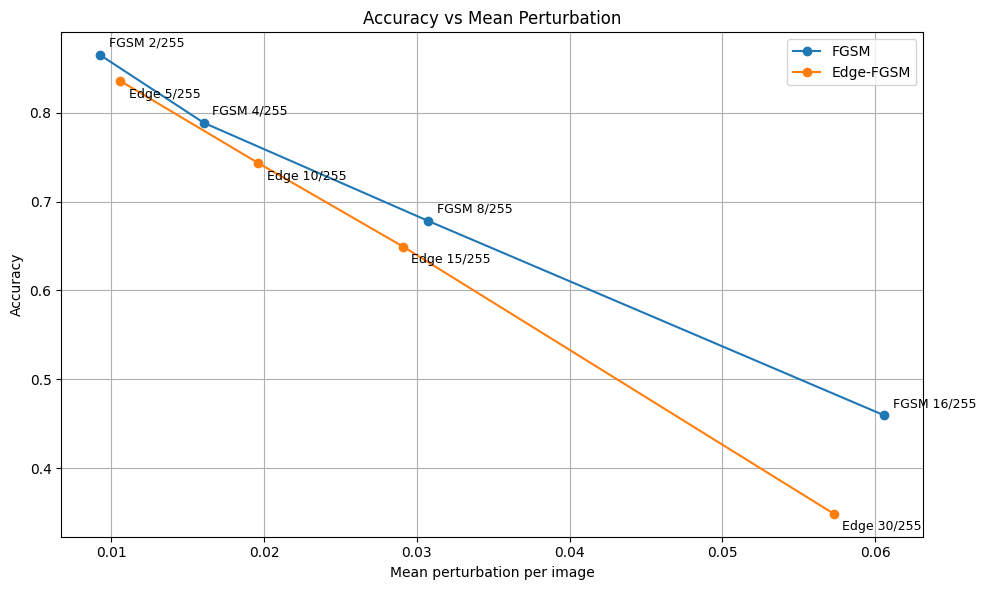

Saved: /content/attack_FGSM/summary/accuracy_vs_mean_perturbation_fgsm_edgefgsm.png


In [11]:
# 11. Accuracy vs. mean perturbation plot
plot_df = accuracy_df.merge(
    pixel_summary_df[['attack', 'mean_of_mean_abs_pixel_change']],
    on='attack',
    how='left',
)
plot_df.loc[plot_df['attack'] == 'Clean', 'mean_of_mean_abs_pixel_change'] = 0.0

def eps_from_name(name):
    return int(name.split()[-1].replace('/255', ''))

fgsm_plot = plot_df[plot_df['attack'].str.startswith('FGSM')].copy()
edge_plot = plot_df[plot_df['attack'].str.startswith('Edge-FGSM')].copy()
fgsm_plot['eps'] = fgsm_plot['attack'].apply(eps_from_name)
edge_plot['eps'] = edge_plot['attack'].apply(eps_from_name)

fgsm_plot = fgsm_plot.sort_values('eps')
edge_plot = edge_plot.sort_values('eps')

plt.figure(figsize=(10, 6))
plt.plot(fgsm_plot['mean_of_mean_abs_pixel_change'], fgsm_plot['accuracy'], marker='o', label='FGSM')
plt.plot(edge_plot['mean_of_mean_abs_pixel_change'], edge_plot['accuracy'], marker='o', label='Edge-FGSM')

for _, row in fgsm_plot.iterrows():
    plt.annotate(f"FGSM {row['eps']}/255", (row['mean_of_mean_abs_pixel_change'], row['accuracy']), textcoords='offset points', xytext=(6, 6), fontsize=9)
for _, row in edge_plot.iterrows():
    plt.annotate(f"Edge {row['eps']}/255", (row['mean_of_mean_abs_pixel_change'], row['accuracy']), textcoords='offset points', xytext=(6, -12), fontsize=9)

plt.title('Accuracy vs Mean Perturbation')
plt.xlabel('Mean perturbation per image')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_path = os.path.join(summary_dir, 'accuracy_vs_mean_perturbation_fgsm_edgefgsm.png')
plt.savefig(plot_path, dpi=200)
plt.show()
print('Saved:', plot_path)

In [12]:
# 12. Same-index visual comparison
def predict_image(root, rel_path):
    img = Image.open(os.path.join(root, rel_path)).convert('RGB')
    x = eval_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return model(x).argmax(dim=1).item()

def show_same_index_comparison(sample_idx=0, show_pred=False):
    row = test_df.iloc[sample_idx]
    rel_path = row['Path']
    true_label = int(row['ClassId'])

    items = [('Original', GTSRB_ROOT)]
    items += [(f'FGSM {e}/255', fgsm_root(e)) for e in FGSM_EPS_LIST]
    items += [(f'Edge-FGSM {e}/255', edge_root(e)) for e in EDGE_EPS_LIST]

    ncols = 3
    nrows = math.ceil(len(items) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (title, root) in zip(axes, items):
        img = Image.open(os.path.join(root, rel_path)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        pred_text = f' | Pred: {predict_image(root, rel_path)}' if show_pred else ''
        ax.imshow(img)
        ax.set_title(f'{title}\nTrue: {true_label}{pred_text}', fontsize=11)
        ax.axis('off')

    for ax in axes[len(items):]:
        ax.axis('off')

    plt.suptitle(f'Index={sample_idx} | {rel_path}', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

show_same_index_comparison(sample_idx=0, show_pred=False)

Output hidden; open in https://colab.research.google.com to view.

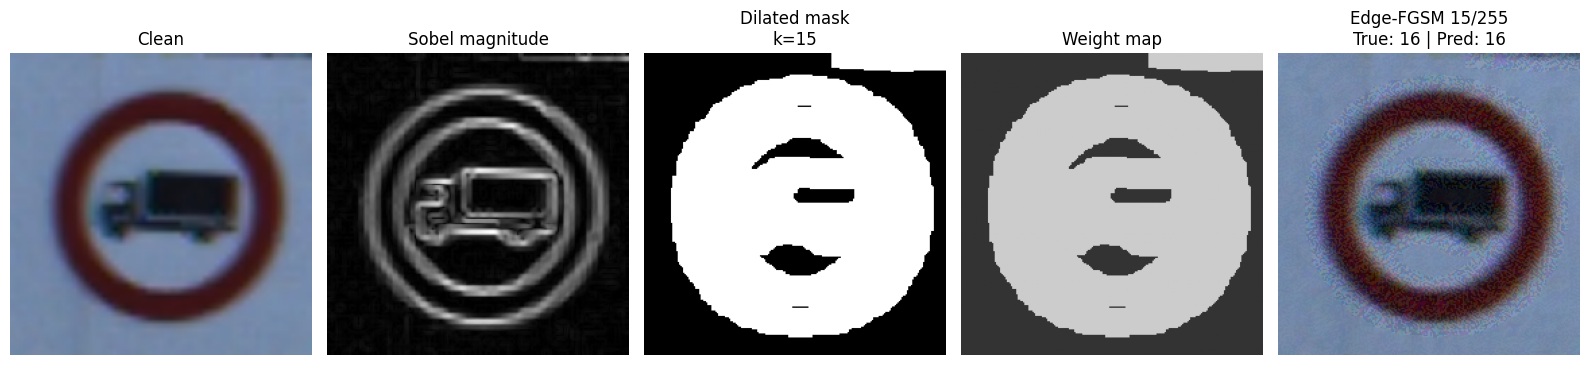

In [13]:
# 13. Edge mask pipeline visualization
def show_edge_mask_pipeline(sample_idx=0, edge_eps_255=15):
    row = test_df.iloc[sample_idx]
    rel_path = row['Path']
    true_label = int(row['ClassId'])

    img = Image.open(os.path.join(GTSRB_ROOT, rel_path)).convert('RGB')
    clean = plain_transform(img).unsqueeze(0).to(DEVICE)

    x = clean.clone().detach().requires_grad_(True)
    model.zero_grad(set_to_none=True)
    criterion(model(normalize_batch(x)), torch.tensor([true_label], device=DEVICE)).backward()

    grad_sign = x.grad.detach().sign()

    with torch.no_grad():
        edge_response, mask = edge_mask_batch(clean)
        weight = EDGE_WEIGHT * mask + NON_EDGE_WEIGHT * (1.0 - mask)
        adv = torch.clamp(clean + (edge_eps_255 / 255.0) * weight.repeat(1, 3, 1, 1) * grad_sign, 0.0, 1.0)
        pred = model(normalize_batch(adv)).argmax(dim=1).item()

    fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
    titles = [
        'Clean',
        'Sobel magnitude',
        f'Dilated mask\nk={DILATION_KERNEL}',
        'Weight map',
        f'Edge-FGSM {edge_eps_255}/255\nTrue: {true_label} | Pred: {pred}',
    ]
    images = [
        clean[0].detach().cpu().permute(1, 2, 0).numpy(),
        edge_response[0, 0].detach().cpu().numpy(),
        mask[0, 0].detach().cpu().numpy(),
        weight[0, 0].detach().cpu().numpy(),
        adv[0].detach().cpu().permute(1, 2, 0).numpy(),
    ]

    for ax, title, image in zip(axes, titles, images):
        ax.imshow(image, cmap='gray' if image.ndim == 2 else None, vmin=0 if image.ndim == 2 else None, vmax=1 if image.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_edge_mask_pipeline(sample_idx=0, edge_eps_255=15)